#  Machine Learning-Based Prediction of 30-Day Hospital Readmission Using PySpark

## Imports

In [105]:
from pyspark.sql import SparkSession
import pyspark.sql.functions as sql_f
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import MulticlassClassificationEvaluator, BinaryClassificationEvaluator
from pyspark.ml.classification import RandomForestClassifier, DecisionTreeClassifier ,LogisticRegression
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder

## Start Spark Session


In [79]:
spark = SparkSession.builder \
    .master("local[*]") \
    .appName("Hospital Readmission") \
    .getOrCreate()

spark.sparkContext.setLogLevel("ERROR")
print("Spark session started successfully.")

Spark session started successfully.


##  Load the Dataset


In [80]:
file_path = "hospital_readmissions_30k.csv"
df = spark.read.csv(file_path, header=True, inferSchema=True)
df.cache()
df.show(5)

+----------+---+------+--------------+-----------+----+--------+------------+----------------+--------------+---------------------+------------------+
|patient_id|age|gender|blood_pressure|cholesterol| bmi|diabetes|hypertension|medication_count|length_of_stay|discharge_destination|readmitted_30_days|
+----------+---+------+--------------+-----------+----+--------+------------+----------------+--------------+---------------------+------------------+
|         1| 74| Other|        130/72|        240|31.5|     Yes|          No|               5|             1|     Nursing_Facility|               Yes|
|         2| 46|Female|        120/92|        292|36.3|      No|          No|               4|             3|     Nursing_Facility|                No|
|         3| 89| Other|        135/78|        153|30.3|      No|         Yes|               1|             1|                 Home|                No|
|         4| 84|Female|        123/80|        153|31.5|      No|         Yes|               3|

In [81]:
df.printSchema()

root
 |-- patient_id: integer (nullable = true)
 |-- age: integer (nullable = true)
 |-- gender: string (nullable = true)
 |-- blood_pressure: string (nullable = true)
 |-- cholesterol: integer (nullable = true)
 |-- bmi: double (nullable = true)
 |-- diabetes: string (nullable = true)
 |-- hypertension: string (nullable = true)
 |-- medication_count: integer (nullable = true)
 |-- length_of_stay: integer (nullable = true)
 |-- discharge_destination: string (nullable = true)
 |-- readmitted_30_days: string (nullable = true)



In [82]:
print("Number of rows:", df.count())
print("Number of columns:", len(df.columns))

Number of rows: 30000
Number of columns: 12


In [83]:
df.columns

['patient_id',
 'age',
 'gender',
 'blood_pressure',
 'cholesterol',
 'bmi',
 'diabetes',
 'hypertension',
 'medication_count',
 'length_of_stay',
 'discharge_destination',
 'readmitted_30_days']

## Data Preprocessing

In [84]:
# Missing values for each column
missing_counts = df.select([
    sql_f.count(
        sql_f.when(
            sql_f.col(c).isNull() | (sql_f.trim(sql_f.col(c).cast("string")) == ""),c)).alias(c)
    for c in df.columns])

missing_dict = missing_counts.collect()[0].asDict()
has_missing = False

for column, count in missing_dict.items():
    if count > 0:
        print(f"{column}: {count} missing values")
        has_missing = True

if not has_missing:
    print("No missing values found in the dataset")

No missing values found in the dataset


In [85]:
# Duplicate patient IDs
total_rows = df.count()
unique_patient_ids = df.select("patient_id").distinct().count()
duplicate_patient_ids = total_rows - unique_patient_ids

print("Unique patient IDs:", unique_patient_ids)
print("Duplicate patient IDs:", duplicate_patient_ids)

Unique patient IDs: 30000
Duplicate patient IDs: 0


##  Feature Preparation for EDA

In [86]:
df_eda = df \
    .withColumn("systolic_bp", sql_f.split(sql_f.col("blood_pressure"), "/").getItem(0).cast("int")) \
    .withColumn("readmitted_binary", sql_f.when(sql_f.col("readmitted_30_days") == "Yes", 1).otherwise(0))

df_eda.select("patient_id", "blood_pressure", "systolic_bp", "readmitted_30_days", "readmitted_binary").show(10)

+----------+--------------+-----------+------------------+-----------------+
|patient_id|blood_pressure|systolic_bp|readmitted_30_days|readmitted_binary|
+----------+--------------+-----------+------------------+-----------------+
|         1|        130/72|        130|               Yes|                1|
|         2|        120/92|        120|                No|                0|
|         3|        135/78|        135|                No|                0|
|         4|        123/80|        123|                No|                0|
|         5|        135/84|        135|                No|                0|
|         6|       139/100|        139|                No|                0|
|         7|        139/79|        139|                No|                0|
|         8|        153/81|        153|                No|                0|
|         9|        111/76|        111|                No|                0|
|        10|        142/72|        142|                No|                0|

## Outlier Detection

In [87]:
# Outlier Detection Using IQR

df_outlier = df_eda

numeric_cols = [
    "age",
    "bmi",
    "cholesterol",
    "medication_count",
    "length_of_stay",
    "systolic_bp"]

# Convert columns to double
for col in numeric_cols:
    df_outlier = df_outlier.withColumn(
        col,
        sql_f.col(col).cast("double")
    )

outlier_dict = {}
has_outliers = False

for col in numeric_cols:
    temp = df_outlier.filter(sql_f.col(col).isNotNull())

    Q1 = temp.approxQuantile(col, [0.25], 0.01)[0]
    Q3 = temp.approxQuantile(col, [0.75], 0.01)[0]
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outlier_count = temp.filter(
        (sql_f.col(col) < lower) | (sql_f.col(col) > upper)
    ).count()

    outlier_dict[col] = outlier_count

# Print results
for column, count in outlier_dict.items():
    if count > 0:
        print(f"{column}: {count} outliers")
        has_outliers = True

if not has_outliers:
    print("No outliers found using the IQR method")

No outliers found using the IQR method


##  Descriptive Statistics for Numerical Variables

In [88]:
numeric_cols = [
    "age",
    "cholesterol",
    "bmi",
    "medication_count",
    "length_of_stay",
    "systolic_bp"]

df_eda.select(numeric_cols).summary("count", "min", "mean", "stddev", "50%", "max").show()

+-------+------------------+-----------------+------------------+------------------+-----------------+------------------+
|summary|               age|      cholesterol|               bmi|  medication_count|   length_of_stay|       systolic_bp|
+-------+------------------+-----------------+------------------+------------------+-----------------+------------------+
|  count|             30000|            30000|             30000|             30000|            30000|             30000|
|    min|                18|              150|              18.0|                 0|                1|               110|
|   mean|53.884233333333334|         225.2604|28.946263333333288| 5.012266666666667|           5.5029|134.96833333333333|
| stddev|21.056484605231493|43.58567098864616| 6.348203895098614|3.1663833830328345|2.867298200391038|14.671463422242066|
|    50%|                54|              225|              28.9|                 5|                5|               135|
|    max|               

## Feature Engineering for Machine Learning

In [89]:


# Define categorical columns
categoricalCols = [
    "gender",
    "diabetes",
    "hypertension",
    "discharge_destination"
]


# Convert categorical text columns into numerical index values
indexers = [
    StringIndexer(
        inputCol=col,
        outputCol=col + "_index",
        handleInvalid="keep"
    )
    for col in categoricalCols
]


# Apply OneHotEncoding to indexed categorical columns
# This prevents the model from assuming ordinal relationships
encoders = [
    OneHotEncoder(
        inputCol=col + "_index",
        outputCol=col + "_vec"
    )
    for col in categoricalCols
]


# Define numerical columns used as input features
numericCols = [
    "age",
    "cholesterol",
    "bmi",
    "medication_count",
    "length_of_stay",
    "systolic_bp"
]


# Combine numerical and encoded categorical features
featuresCols = numericCols + [col + "_vec" for col in categoricalCols]


# Assemble all features into a single vector column
vectorAssembler = VectorAssembler(
    inputCols=featuresCols,
    outputCol="features"
)

## Split the Data

In [90]:
# Prepare dataset for ML models
df_ml = df \
    .withColumn(
        "systolic_bp",
        sql_f.split(sql_f.col("blood_pressure"), "/").getItem(0).cast("int")
    ) \
    .withColumn(
        "label",
        sql_f.when(sql_f.col("readmitted_30_days") == "Yes", 1).otherwise(0)
    )

df_ml.printSchema()

root
 |-- patient_id: integer (nullable = true)
 |-- age: integer (nullable = true)
 |-- gender: string (nullable = true)
 |-- blood_pressure: string (nullable = true)
 |-- cholesterol: integer (nullable = true)
 |-- bmi: double (nullable = true)
 |-- diabetes: string (nullable = true)
 |-- hypertension: string (nullable = true)
 |-- medication_count: integer (nullable = true)
 |-- length_of_stay: integer (nullable = true)
 |-- discharge_destination: string (nullable = true)
 |-- readmitted_30_days: string (nullable = true)
 |-- systolic_bp: integer (nullable = true)
 |-- label: integer (nullable = false)



In [ ]:
# Handle class imbalance: give the minority class (Readmitted) a higher weight
balance_ratio = df_ml.filter(sql_f.col("label") == 0).count() / df_ml.filter(sql_f.col("label") == 1).count()

df_ml = df_ml.withColumn(
    "classWeight",
    sql_f.when(sql_f.col("label") == 1, balance_ratio).otherwise(1.0)
)

print("Balance ratio (majority/minority):", balance_ratio)
df_ml.select("label", "classWeight").show(5)


In [91]:
seed = 123456

df_train, df_test = df_ml.randomSplit([0.7, 0.3], seed)

print("Training Count:", df_train.count())
print("Testing Count:", df_test.count())

Training Count: 21002
Testing Count: 8998


## Data Visualization

## Target Variable Distribution



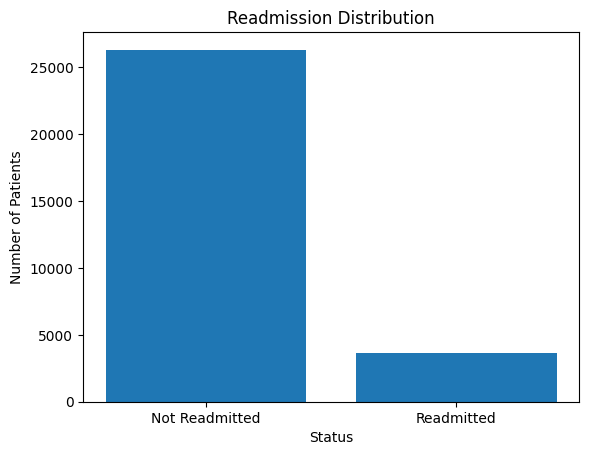

In [92]:

data = df.groupBy("readmitted_30_days").count().toPandas()

data["readmitted_30_days"] = data["readmitted_30_days"].replace({
    "No": "Not Readmitted",
    "Yes": "Readmitted"
})

plt.bar(data["readmitted_30_days"], data["count"])
plt.title("Readmission Distribution")
plt.xlabel("Status")
plt.ylabel("Number of Patients")
plt.show()

The bar chart shows the distribution of patients based on 30-day readmission.
It is clear that the majority of patients were not readmitted, while a smaller portion were readmitted.
This indicates that the dataset is imbalanced.

## Feature Correlation Heatmap

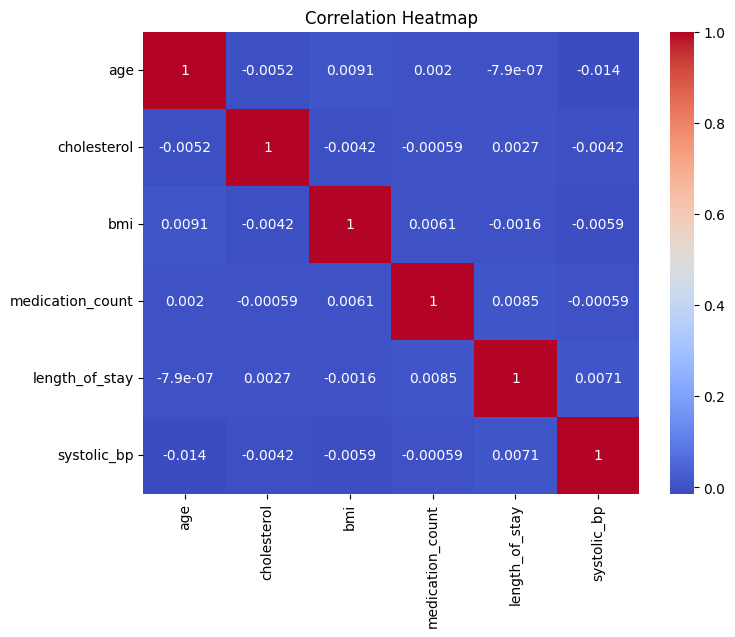

In [93]:
pdf = df_eda.toPandas()

numeric_cols = ["age", "cholesterol", "bmi", "medication_count", "length_of_stay", "systolic_bp"]

corr = pdf[numeric_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

The correlation heatmap shows the relationships between numerical variables in the dataset.
Most correlation values are very close to zero, indicating that there are no strong linear relationships between the variables.
This suggests that each feature provides independent information, which can be beneficial for machine learning models.

## Readmission Rate by Diabetes and Hypertension

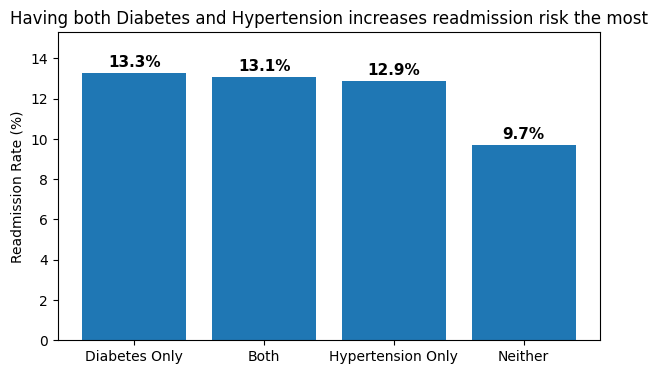

In [94]:
# Readmission rate by diabetes & hypertension combination
comorbidity_pd = (
    df_eda
    .withColumn(
        "condition",
        sql_f.when((sql_f.col("diabetes")=="Yes") & (sql_f.col("hypertension")=="Yes"), "Both")
         .when(sql_f.col("diabetes")=="Yes", "Diabetes Only")
         .when(sql_f.col("hypertension")=="Yes", "Hypertension Only")
         .otherwise("Neither")
    )
    .groupBy("condition")
    .agg(sql_f.round(sql_f.avg("readmitted_binary")*100,1).alias("rate"))
    .orderBy(sql_f.desc("rate"))
    .toPandas()
)

plt.figure(figsize=(7,4))
bars = plt.bar(comorbidity_pd["condition"], comorbidity_pd["rate"])


for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, y + 0.3,
             f"{y}%", ha='center', fontsize=11, fontweight='bold')

plt.title("Having both Diabetes and Hypertension increases readmission risk the most")
plt.ylabel("Readmission Rate (%)")
plt.ylim(0, max(comorbidity_pd["rate"]) + 2)

plt.show()

The chart shows the readmission rates for different patient groups based on diabetes and hypertension conditions. Patients with diabetes only recorded the highest readmission rate, followed by patients with both diabetes and hypertension, while patients with neither condition had the lowest readmission rate. This suggests that chronic conditions significantly increase the risk of hospital readmission.

# Readmission Rate by Discharge Destination

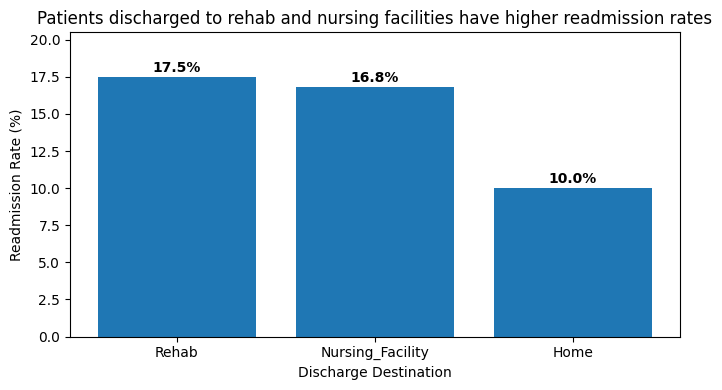

In [95]:
discharge_pd = (
    df_eda.groupBy("discharge_destination")
    .agg((sql_f.avg("readmitted_binary") * 100).alias("rate"))
    .orderBy(sql_f.desc("rate"))
    .toPandas()
)

plt.figure(figsize=(7,4))
bars = plt.bar(discharge_pd["discharge_destination"], discharge_pd["rate"])

for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, y + 0.3,
             f"{y:.1f}%", ha='center', fontweight='bold')

plt.title("Patients discharged to rehab and nursing facilities have higher readmission rates")
plt.xlabel("Discharge Destination")
plt.ylabel("Readmission Rate (%)")

plt.ylim(0, max(discharge_pd["rate"]) + 3)
plt.tight_layout()
plt.show()

This chart shows the 30-day readmission rate for patients based on their discharge destination. Patients discharged to rehabilitation centers and nursing facilities have higher readmission rates compared to those discharged home. This suggests that patients who require additional care after discharge are at a higher risk of being readmitted.

## Build Models

In [103]:
# Evaluation metric used for model selection
evaluator_f1 = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="f1"
)

In [ ]:
# Logistic Regression

lr = LogisticRegression(
    labelCol="label",
    featuresCol="features",
    weightCol="classWeight"
)

paramGrid_lr = ParamGridBuilder() \
    .addGrid(lr.regParam, [0.01, 0.1]) \
    .addGrid(lr.maxIter, [10, 20]) \
    .build()

cv_lr = CrossValidator(
    estimator=lr,
    evaluator=evaluator_f1,
    estimatorParamMaps=paramGrid_lr,
    numFolds=3
)

pipeline_lr = Pipeline(
    stages=indexers + encoders + [vectorAssembler, cv_lr]
)

pipeline_model_lr = pipeline_lr.fit(df_train)

predictions_lr = pipeline_model_lr.transform(df_test)


In [ ]:
# Confusion matrix - Logistic Regression
predictions_lr.groupBy("label", "prediction").count().orderBy("label", "prediction").show()


In [ ]:
# Decision Tree


dt = DecisionTreeClassifier(
    labelCol="label",
    featuresCol="features",
    weightCol="classWeight"
)

paramGrid_dt = ParamGridBuilder() \
    .addGrid(dt.maxDepth, [5, 8]) \
    .addGrid(dt.minInstancesPerNode, [1, 3]) \
    .build()

cv_dt = CrossValidator(
    estimator=dt,
    evaluator=evaluator_f1,
    estimatorParamMaps=paramGrid_dt,
    numFolds=3
)

pipeline_dt = Pipeline(
    stages=indexers + encoders + [vectorAssembler, cv_dt]
)

pipeline_model_dt = pipeline_dt.fit(df_train)

predictions_dt = pipeline_model_dt.transform(df_test)


In [ ]:
# Confusion matrix - Decision Tree
predictions_dt.groupBy("label", "prediction").count().orderBy("label", "prediction").show()


In [ ]:
# Random Forest

rf = RandomForestClassifier(
    labelCol="label",
    featuresCol="features",
    weightCol="classWeight"
)

paramGrid_rf = ParamGridBuilder() \
    .addGrid(rf.numTrees, [20, 50]) \
    .addGrid(rf.maxDepth, [5, 8]) \
    .build()

cv_rf = CrossValidator(
    estimator=rf,
    evaluator=evaluator_f1,
    estimatorParamMaps=paramGrid_rf,
    numFolds=3
)

pipeline_rf = Pipeline(
    stages=indexers + encoders + [vectorAssembler, cv_rf]
)

pipeline_model_rf = pipeline_rf.fit(df_train)

predictions_rf = pipeline_model_rf.transform(df_test)



In [ ]:
# Confusion matrix - Random Forest
predictions_rf.groupBy("label", "prediction").count().orderBy("label", "prediction").show()


## Model Evaluation

In [ ]:
results = []

accuracy_eval   = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")
precision_eval  = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="weightedPrecision")
recall_eval     = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="weightedRecall")
f1_eval         = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="f1")
auc_eval        = BinaryClassificationEvaluator(labelCol="label", rawPredictionCol="rawPrediction", metricName="areaUnderROC")

# Precision/Recall for the positive class only (Readmitted = 1)
precision1_eval = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="precisionByLabel", metricLabel=1)
recall1_eval    = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="recallByLabel", metricLabel=1)


for model_name, predictions in [
    ("Logistic Regression", predictions_lr),
    ("Decision Tree",       predictions_dt),
    ("Random Forest",       predictions_rf)
]:
    results.append((
        model_name,
        accuracy_eval.evaluate(predictions),
        precision_eval.evaluate(predictions),
        recall_eval.evaluate(predictions),
        f1_eval.evaluate(predictions),
        auc_eval.evaluate(predictions),
        precision1_eval.evaluate(predictions),
        recall1_eval.evaluate(predictions)
    ))

results_df = spark.createDataFrame(results, ["Model", "Accuracy", "Precision", "Recall", "F1 Score", "AUC", "Precision (Readmitted)", "Recall (Readmitted)"])
results_df.show(truncate=False)


## Model Comparison Charts

In [108]:
# Convert Spark DataFrame to Pandas
results_pd = results_df.toPandas()

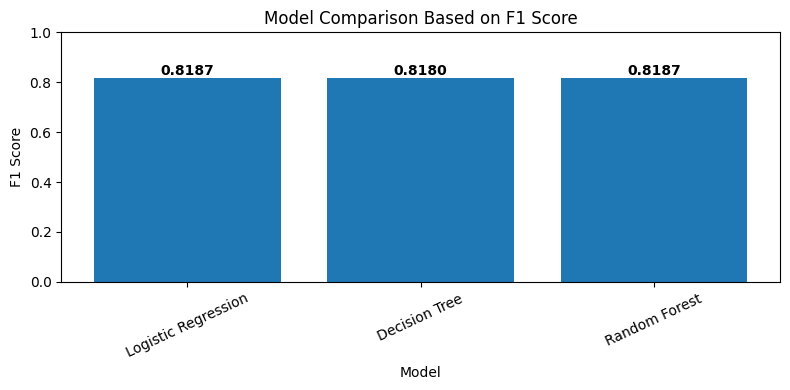

In [109]:
plt.figure(figsize=(8,4))

bars = plt.bar(results_pd["Model"], results_pd["F1 Score"])

for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, y + 0.01,
             f"{y:.4f}", ha="center", fontweight="bold")

plt.title("Model Comparison Based on F1 Score")
plt.xlabel("Model")
plt.ylabel("F1 Score")
plt.xticks(rotation=25)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

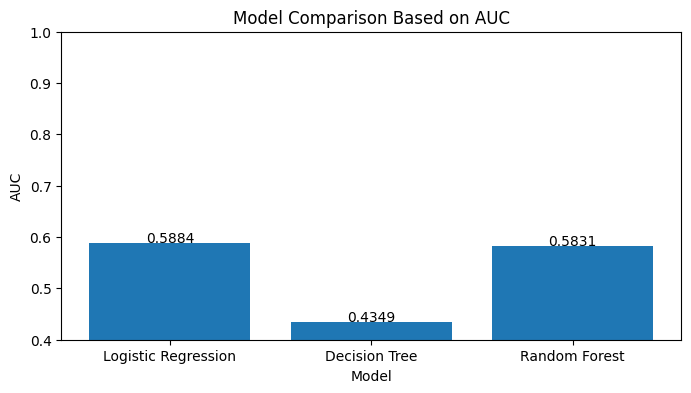

In [115]:
plt.figure(figsize=(8,4))
bars = plt.bar(results_pd["Model"], results_pd["AUC"])

for bar in bars:
    y = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        y + 0.001,
        f"{y:.4f}",
        ha="center"
    )

plt.title("Model Comparison Based on AUC")
plt.xlabel("Model")
plt.ylabel("AUC")

plt.ylim(0.4, 1)

plt.show()

## Handling Class Imbalance

The initial models showed high accuracy and F1-score, but low AUC values (with the Decision Tree even scoring below 0.5), indicating the models were biased toward the majority class ("Not Readmitted") rather than truly distinguishing high-risk patients. To address this, class weighting was applied during training (`classWeight`), giving the minority class (Readmitted) more influence on the loss function. After this change, re-run the notebook and compare the new AUC and Precision/Recall (Readmitted) values against Table II to confirm the models better identify at-risk patients. **[Fill in the updated numbers here after re-running.]**
